# Dinamica di una Rete Neurale attraverso le Equazioni di Campo Medio

## Introduzione

Le Reti Neurali e più in generale i grafi di interazione sono modelli essenziali per descrivere sistemi dinamici, e per prevedere il comportamento emergente di sistemi complessi composti da molteplici componeneti interagenti. Sono utilizzate in molteplici ambiti, ad esempio:

- **Reti elettriche:** per prevedere e prevenire blackout anticipando cambiamenti nella stabilità della rete;
- **Rilevazione di frodi nelle transazioni con carte di credito:** per identificare comportamenti anomali emergenti nel tempo.

Studiare la **dinamica collettiva** di una Rete Neurale significa comprendere come evolve nel tempo l’attivazione media dei neuroni, ed è molto significativo spesso per prevedere le future configurazioni della rete senza analizzare la dinamica di ogni componente.

---

## Dall'energia libera all'equazione dinamica

Consideriamo una dinamica di tipo Ising, definita su un grafo, poichè consideriamo una rete Neurale prendiamo un grafo orientato, per sistemi fisici si considerano, in generale, grafi non orientati (si presuppone che se una componente interagisce con l'altra sia vero il viceversa), poichè per questo tipo di problemi la distribuzione di Boltzmann-Gibbs diventa intrattabile, consideriamo una distribuzione prodotto di variabili indipendenti, (ogni spin assume uno stato o un altro indipendentemente dagli altri spin), che minimizza  il funzionale di Energia Libera $ \mathcal{F}[m] $:

$$
\mathcal{F}[m] = -\frac{1}{2} \sum_{i,j} W_{ij} m_i m_j - \sum_i b_i m_i + T \sum_i s(m_i),
$$

dove:
- $ W \in \mathbb{R}^{N \times N} $ è la matrice dei pesi sinaptici (connessioni tra neuroni), in generale in una rete neurale il grafo orientato e quindi $ W \neq W^{\mathrm{T}}$,

- $ b \in \mathbb{R}^N $ è un vettore di bias (input esterno),
- $ T $ è un parametro analogo alla temperatura,
- $ s(m_i) $ è l'entropia di una variabile binaria con media $ m_i $:

$$
s(m) = \frac{1 + m}{2} \log\left(\frac{1 + m}{2}\right) + \frac{1 - m}{2} \log\left(\frac{1 - m}{2}\right)
$$



Matrice W accettata:[[0. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 1. 1. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 1. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [1. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

Bias b:[ 0.18891286 -0.02218498 -0.14333863 -0.03954743  0.12265226 -0.01934221
  0.06119013 -0.05949894  0.20784006 -0.1996397 ]


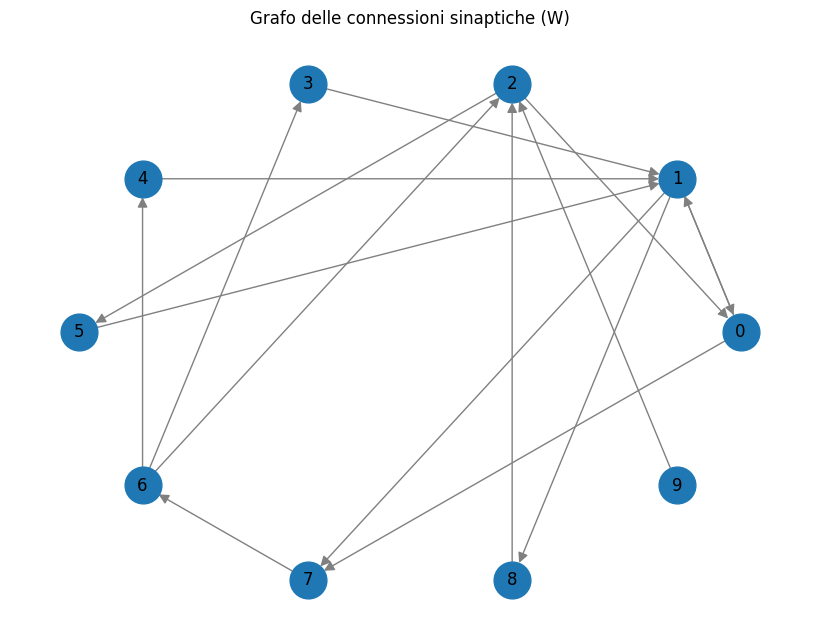

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Funzioni utili
def is_connected(W): #restituisce True se un nodo è conesso almeno a un elemento
    return np.all(W.sum(axis=0) > 0)

def is_connected_enough(W, min_links=10): #restituisce True se il grafo è abbastanza connesso
    return np.sum(W) >= min_links

def generate_connected_W(n, p=0.1, min_links=10):
    while True:
        W = (np.random.rand(n, n) < p).astype(float) #genero numeri random in [0,1] se > p gli assegno 1
        np.fill_diagonal(W, 0) #non considero un nodo connesso con se stesso
        if is_connected(W) and is_connected_enough(W, min_links): #controlli sulla topologia del grafo
            return W

def plot_graph(W):
    G = nx.DiGraph() #importato da networkx per creare un grafo
    n = W.shape[0]
    G.add_nodes_from(range(n)) #aggiungo i nodi con la funzione built-in
    for i in range(n):
        for j in range(n):
            if W[i, j] == 1:
                G.add_edge(j, i) #aggiungo l'arco orientato se è presente connessione nella matrice di adiacenza
    pos = nx.circular_layout(G) #layout grafico circolare dei nod
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_size=700, arrows=True, #plot del grafo
            arrowstyle='-|>', arrowsize=15, edge_color='gray')
    plt.title("Grafo delle connessioni sinaptiche (W)")
    plt.show()

# Parametri di rete
n_neuroni = 10
W = generate_connected_W(n_neuroni)
b = np.random.randn(n_neuroni) * 0.1
m0 = np.random.randn(n_neuroni) * 0.1

# Mostra info
print(f"Matrice W accettata:{W}")
print(f"\nBias b:{b}")

# Plot grafo
plot_graph(W)


Derivando il funzionale otteniamo:

$$
\frac{\partial \mathcal{F}}{\partial m_i} = -\sum_j W_{ij} m_j - b_i + T \cdot \text{arctanh}(m_i)
$$

Per modellare l’evoluzione nel tempo della magnetizzazione media $ m(t) $, consideriamo un sistema che rilassa gradualmente verso una configurazione di equilibrio. In altri termini, descriviamo una dinamica in cui ogni neurone (o spin) si stabilizza nel tempo, avvicinandosi a uno stato stazionario $ m^* $, ovvero una configurazione in cui il sistema smette di evolvere.

Questi **stati stazionari** (che analizzeremo più avanti) soddisfano la condizione:

$$
\frac{d m}{dt} = 0 \quad \Rightarrow \quad m^* = \tanh(W m^* + b)
$$

Vogliamo quindi scrivere un’equazione differenziale che descriva come $ m(t)$ evolva nel tempo verso questi stati stazionari. A questo scopo, introduciamo una dinamica di rilassamento del tipo:

$$
\tau \frac{d m_i}{dt} = -m_i + \tanh\left( \sum_j W_{ij} m_j + b_i \right)
$$

Nel caso particolare in cui $ T = 1 $ e $ \tau = 1 $ (scelte che si possono fare senza perdita di generalità), possiamo riscrivere la dinamica in forma compatta:

$$
\frac{d m}{dt} = -m + \tanh(W m + b)
$$

cioè:

$$
\boxed{
\frac{d m_i}{dt} = -m_i + \tanh\left(\sum_j W_{ij} m_j + b_i\right)
}
$$

Questa dinamica ha come punti fissi le configurazioni $ m^* $ che soddisfano $ m^* = \tanh(W m^* + b) $, verso cui il sistema converge naturalmente nel tempo.

---

## Perché risolvere numericamente?

Queste equazioni che descrivono la dinamica di ogni neurone, non ammettono generalmente soluzioni analitiche semplici, quindi è necessario utilizzare metodi numerici per:

- Simulare l’evoluzione temporale dello stato medio $ m(t) \in \mathbb{R}^N $;
- Studiare la convergenza a stati stazionari o punti di equilibrio;
- Analizzare la stabilità e le transizioni di fase del sistema, che corrispondono a cambiamenti improvvisi nel comportamento collettivo.

---

## Metodo Runge-Kutta 4

Tra i metodi numerici, Runge-Kutta di quarto ordine (RK4) offre un buon compromesso tra accuratezza e complessità computazionale, superando i limiti del semplice metodo di Eulero esplicito.

Ad ogni passo temporale $ \Delta t $, RK4 calcola la nuova approssimazione secondo le formule:

Il metodo di Runge-Kutta del quarto ordine con la funzione $F(t, m)$ è definito come:

$$
\begin{aligned}
k_1 &= F(t_n, m_n), \\\
k_2 &= F\left(t_n + \frac{\Delta t}{2}, m_n + \frac{\Delta t}{2} k_1\right), \\\
k_3 &= F\left(t_n + \frac{\Delta t}{2}, m_n + \frac{\Delta t}{2} k_2\right), \\\
k_4 &= F(t_n + \Delta t, m_n + \Delta t k_3), \\\
m_{n+1} &= m_n + \frac{\Delta t}{6}(k_1 + 2k_2 + 2k_3 + k_4)
\end{aligned}\\\
$$

con $F(m,t)$ definita nel modo seguente:$F(t, m) = -m + \tanh(W m + b)$ dove $m, b \in \mathbb{R}^N$ e $W \in \mathbb{R}^{N \times N}$.

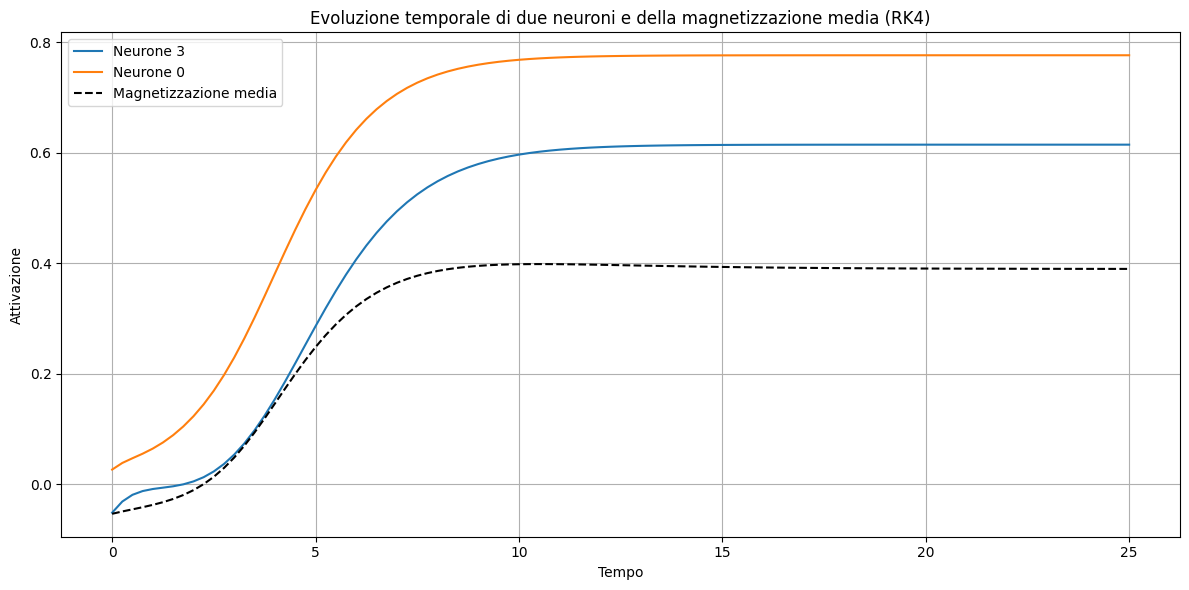

In [ ]:
def F(m, W, b): #funzione campo medio
    return -m + np.tanh(W @ m + b)

def rk4_step(F, m, W, b, dt): #risolvo l'eq differenziale con RK-4
    k1 = F(m, W, b)
    k2 = F(m + dt/2 * k1, W, b)
    k3 = F(m + dt/2 * k2, W, b)
    k4 = F(m + dt * k3, W, b)
    return m + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)

def simulate_rk4(F, m0, W, b, dt, N):
    m = m0.copy() #vettore di m0
    trajectory = [m.copy()] #matrice di dim. (N+1,N_neuroni)
    for _ in range(N):
        m = rk4_step(F, m, W, b, dt) #calcolo la sol. a ogni istante temporale in [0,25]
        trajectory.append(m.copy()) #aggiungo m{n+1} alle soluzioni
    return np.array(trajectory)


# Parametri temporali
T = 25
t0 = 0
N = 100
dt = (T - t0) / N

# Simulazione RK4
traj = simulate_rk4(F, m0, W, b, dt, N)
time = np.linspace(t0, T, N + 1)
magnetization = np.mean(traj, axis=1)

# Selezione due neuroni
i, j = np.random.choice(len(m0), 2, replace=False)

# Plot traiettorie
plt.figure(figsize=(12, 6))
plt.plot(time, traj[:, i], label=f"Neurone {i}")
plt.plot(time, traj[:, j], label=f"Neurone {j}")
plt.plot(time, magnetization, label="Magnetizzazione media", linestyle='--', color='black')

plt.title("Evoluzione temporale di due neuroni e della magnetizzazione media (RK4)")
plt.xlabel("Tempo")
plt.ylabel("Attivazione")
plt.grid(True)
plt.legend()
plt.tight_layout()

### Verifica della consistenza del metodo

Il metodo RK4 ha la seguente **tabella di Butcher**:

$$
\begin{array}{c|cccc}
0   & 0   & 0   & 0   & 0   \\
\frac{1}{2} & \frac{1}{2} & 0   & 0   & 0   \\
\frac{1}{2} & 0   & \frac{1}{2} & 0   & 0   \\
1   & 0   & 0   & 1   & 0   \\
\hline
    & \frac{1}{6} & \frac{1}{3} & \frac{1}{3} & \frac{1}{6}
\end{array}
$$

e poichè vale che:

$$
\sum_{i=1}^s b_i = 1 \quad \text{e} \quad c_i = \sum_{j=1}^s a_{ij} \quad \forall i.
$$

il metodo RK4 è **consistente**.

---

### 1. Stadi del metodo RK4

Si pone:

$$
\begin{aligned}
k_1 &= f(y_t, t) \\
k_2 &= f\left(y_t + \frac{h}{2}k_1,\, t + \frac{h}{2} \right) \\
k_3 &= f\left(y_t + \frac{h}{2}k_2,\, t + \frac{h}{2} \right) \\
k_4 &= f\left(y_t + h k_3,\, t + h \right)
\end{aligned}
$$

Sviluppiamo ciascun termine:

$$
\begin{array}{rl}
k_2 &= f\left( y_t + \frac{h}{2}k_1,\, t + \frac{h}{2} \right) = f(y_t, t) + \frac{h}{2} \frac{d}{dt} f(y_t, t) \\
k_3 &= f\left( y_t + \frac{h}{2} f\left( y_t + \frac{h}{2}k_1,\, t + \frac{h}{2} \right),\, t + \frac{h}{2} \right) \\
    &= f(y_t, t) + \frac{h}{2} \frac{d}{dt} \left[ f(y_t, t) + \frac{h}{2} \frac{d}{dt} f(y_t, t) \right] \\
k_4 &= f\left( y_t + h f\left( y_t + \frac{h}{2}k_2,\, t + \frac{h}{2} \right),\, t + h \right) \\
    &= f(y_t, t) + h \frac{d}{dt} \left[ f(y_t, t) + \frac{h}{2} \frac{d}{dt} \left[ f(y_t, t) + \frac{h}{2} \frac{d}{dt} f(y_t, t) \right] \right]
\end{array}
$$

Considero allora $y(t+h) $ definito nel modo seguente:

$$
\begin{aligned}
y_{t+h} &= y_t + h \left\{
a \cdot f(y_t, t)
+ b \cdot \left[ f(y_t, t) + \frac{h}{2} \frac{d}{dt} f(y_t, t) \right] \right. \\
&\quad + c \cdot \left[ f(y_t, t) + \frac{h}{2} \frac{d}{dt} \left[ f(y_t, t) + \frac{h}{2} \frac{d}{dt} f(y_t, t) \right] \right] \\
&\quad \left. + d \cdot \left[ f(y_t, t) + h \frac{d}{dt} \left[ f(y_t, t) + \frac{h}{2} \frac{d}{dt} \left[ f(y_t, t) + \frac{h}{2} \frac{d}{dt} f(y_t, t) \right] \right] \right]
\right\} + \mathcal{O}(h^5)
\end{aligned}
$$

Sviluppando i termini:

$$
\begin{aligned}
y_{t+h} = y_t
&+ a \cdot h f_t
+ b \cdot h f_t + b \cdot \frac{h^2}{2} \frac{d f_t}{dt} \\
&+ c \cdot h f_t + c \cdot \frac{h^2}{2} \frac{d f_t}{dt} + c \cdot \frac{h^3}{4} \frac{d^2 f_t}{dt^2} \\
&+ d \cdot h f_t + d \cdot h^2 \frac{d f_t}{dt} + d \cdot \frac{h^3}{2} \frac{d^2 f_t}{dt^2} + d \cdot \frac{h^4}{4} \frac{d^3 f_t}{dt^3}
+ \mathcal{O}(h^5)
\end{aligned}
$$

---

### Espansione di Taylor

Sviluppando la soluzione esatta $ y(t+h) $ in serie di Taylor attorno a $ t $:

$$
y(t + h) = y_t + h f + \frac{h^2}{2} \dot{f}_t + \frac{h^3}{6} \ddot{f}_t + \frac{h^4}{24} f^{(3)}_t + \mathcal{O}(h^5)
$$

Imponendo che l'espansione numerica coincida con quella di Taylor, otteniamo il sistema:

$$
\begin{cases}
a + b + c + d = 1 \\
\frac{b}{2} + \frac{c}{2} + d = \frac{1}{2} \\
\frac{c}{4} + \frac{d}{2} = \frac{1}{6} \\
\frac{d}{6} = \frac{1}{24}
\end{cases}
\quad \Rightarrow \quad
\boxed{
a = \frac{1}{6}, \quad b = \frac{1}{3}, \quad c = \frac{1}{3}, \quad d = \frac{1}{6}
}
$$

---
### Derivata approssimata tramite differenze finite

Nel metodo RK4, la soluzione viene aggiornata secondo:

$$
y_{j+1} = y_j + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4) + \mathcal{O}(h^5),
$$

dove il termine $ \mathcal{O}(h^5) $ rappresenta **l’errore residuo** dell'approssimazione rispetto alla soluzione esatta $ y(t_{j+1}) $, come ottenuto tramite sviluppo in serie di Taylor.

Calcolando la differenza finita in avanti:

$$
\frac{y_{j+1} - y_j}{h} = \frac{1}{6}(k_1 + 2k_2 + 2k_3 + k_4) + \mathcal{O}(h^4),
$$

ossia l'approssimazione della derivata $ \dot{y}(t_j) $ è **di ordine 4**.

In conclusione:

$$
\boxed{
\frac{y_{j+1} - y_j}{h} = \dot{y}(t_j) + \mathcal{O}(h^4)
}
$$

L’errore $ \mathcal{O}(h^4) $ deriva dal fatto che l’approssimazione $ y_{j+1} $ è corretta fino a $ \mathcal{O}(h^5) $, e la differenza finita divide per $ h $, riducendo l’ordine di uno.



### Errore residuo e troncamento

Dalla differenza tra l’espansione esatta e quella del metodo RK4:

$$
\varepsilon(h) = y(t+h) - y_{t+h} = \mathcal{O}(h^5)
$$

Definiamo l'errore di troncamento locale come:

$$
\tau(h) = \frac{\varepsilon(h)}{h} = \mathcal{O}(h^4)
$$

---

### Convergenza del metodo RK4

Poiché abbiamo dimostrato che il metodo RK4 è **consistente**, e in particolare che l'errore di troncamento locale è:

$$
\tau(h) = \mathcal{O}(h^4),
$$

e poiché RK4 è un **metodo a singolo passo**, la **zero-stabilità** è garantita se la funzione del metodo è **Lipschitz continua** rispetto a $ y_t $.

Nel caso di RK4, la funzione:

$$
y_t \mapsto y_{t+h} = y_t + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)
$$

è Lipschitz continua (dato che lo è $ f(t, y) $ per ipotesi), quindi il metodo è **zero-stabile**.

Allora, per il **teorema di Lax-Richtmyer**, un **metodo a singolo passo** che è **consistente** e **zero-stabile** è anche **convergente**.
 Per quanto rigurda la regione di assolutà stabilità del metodo, ne discuteremo in seguito quando avremo una visione più ampia del problema che stiamo trattando.

## Punti stazionari della dinamica: introduzione al metodo di Newton

Abbiamo visto che la dinamica collettiva della rete segue un’equazione del tipo:

$$
\tau \frac{d m}{dt} = -\nabla \mathcal{F}(m)
$$

che implica che l’energia libera $ \mathcal{F}[m(t)] $ decresce nel tempo secondo:

$$
\frac{d}{dt} \mathcal{F}(m(t)) = -\frac{1}{\tau} \| \nabla \mathcal{F}(m) \|^2 \leq 0
$$

Il sistema quindi evolve naturalmente verso **stati stazionari** $ m^* $, che soddisfano:

$$
\frac{d m}{dt} = 0 \quad \Rightarrow \quad \nabla \mathcal{F}(m^*) = 0
$$

cioè:

$$
m^* = \tanh(W m^* + b)
$$
## Metodo di Newton per il punto fisso

Per risolvere numericamente il sistema non lineare:

$$
f(m) = -m + \tanh(Wm + b) = 0
$$

utilizziamo il **metodo di Newton**, che aggiorna iterativamente:

$$
m^{(k+1)} = m^{(k)} - J(m^{(k)})^{-1} f(m^{(k)})
$$

dove la Jacobiana ha la forma:

$$
J(m) = -I + \text{diag}(1 - \tanh^2(Wm + b)) \cdot W
$$

## Metodo di Newton e convergenza locale

Per risolvere numericamente il sistema non lineare:

$$
f(m) = -m + \tanh(Wm + b) = 0,
$$

applichiamo il **metodo di Newton multivariato**, che aggiorna iterativamente:

$$
m^{(k+1)} = m^{(k)} - J(m^{(k)})^{-1} f(m^{(k)}),
$$

dove la Jacobiana $J(m)$ è data da:

$$
J(m) = -I + \text{diag}(1 - \tanh^2(Wm + b)) \cdot W.
$$

### Teorema di convergenza locale

Se $f$ è di classe $\mathcal{C}^1$ in un intorno di un punto $m^* \in \mathbb{R}^n$ tale che $f(m^*) = 0$ e $J(m^*)$ è **invertibile**, limitato e Lipschitz,   allora **esiste $\delta > 0$** tale che, per ogni $m_0 \in B_\delta(m^*)$, la successione $\{m^{(k)}\}$ è **ben definita** e converge a $m^*$.

Nel nostro caso:

- $f(m) = -m + \tanh(Wm + b)$ è di classe $\mathcal{C}^\infty$
- $J(m) = -I + D(m)W$, con $D(m) = \text{diag}(1 - \tanh^2(Wm + b)) \in [0,1]$
- Se $\|D(m)W\| < 1$, allora tutti gli **autovalori di $J(m)$** hanno parte reale negativa $\Rightarrow$ **Jacobiana invertibile**

Per dimostrarlo rigorosamente, e capire da dove salta fuori questa condizione su $J(m)$ vediamo il seguente teorema:
### Teorema (Perturbazione degli autovalori di matrici diagonalizzabili)

Sia $A \in \mathbb{C}^{n \times n}$ una matrice diagonalizzabile, e sia $E \in \mathbb{C}^{n \times n}$ una matrice di perturbazione. Allora, per ogni autovalore $\mu \in \sigma(A + E)$, esiste un autovalore $\lambda \in \sigma(A)$ tale che:

$$
\min_{\lambda \in \sigma(A)} |\mu - \lambda| \leq \kappa(X) \cdot \|E\|,
$$


### 1.Dimostrazione

Sia $ \mu \in \sigma(A + E) $, allora per definizione di autovalore si ha:

$$
\det(A + E - \mu I) = 0.
$$

Sappiamo che $ A = X \Lambda X^{-1} $, quindi:

$$
A + E - \mu I = X \Lambda X^{-1} + E - \mu I.
$$

Moltiplichiamo a sinistra per $ X^{-1} $ e a destra per $ X $, ottenendo:

$$
X^{-1} (A + E - \mu I) X = \Lambda + X^{-1} E X - \mu I =: \Lambda + \Delta - \mu I.
$$

Allora:

$$
\det(\Lambda + \Delta - \mu I) = 0.
$$

Poniamo:

$$
M := (\Lambda - \mu I)^{-1} \Delta.
$$

Allora:

$$
0 = \det((\Lambda - \mu I)(I + M)) = \det(\Lambda - \mu I) \cdot \det(I + M).
$$

Poiché stiamo assumendo che $ \mu \notin \sigma(\Lambda) $ (cioè non è autovalore di $ A $, altrimenti la tesi è banale), allora $\det(\Lambda - \mu I) \ne 0 $, per cui:

$$
\det(I + M) = 0.
$$

Poiché $\det(I + M) = 0$, significa che **la matrice $I + M$ non è invertibile**, cioè:

$$
\exists v \neq 0 \quad \text{tale che} \quad (I + M)v = 0 \quad \Rightarrow \quad Mv = -v.
$$


Quindi $-1$ è un autovalore di $M = (\Lambda - \mu I)^{-1} \Delta$.

Dunque, $ -1 $ è un autovalore di $ M = (\Lambda - \mu I)^{-1} \Delta $, cioè:

$$
-1 \in \sigma\left((\Lambda - \mu I)^{-1} \Delta\right).
$$


Ricorda che:

$$
\|(\Lambda - \mu I)^{-1} \Delta\| \geq 1,
$$

perché contiene $ -1 $ come autovalore, per il teorema di Hirsch.

Ma:

$$
\|(\Lambda - \mu I)^{-1} \Delta\| \leq \|(\Lambda - \mu I)^{-1}\| \cdot \|\Delta\| = \max_{\lambda \in \sigma(A)} \frac{1}{|\lambda - \mu|} \cdot \|X^{-1} E X\|.
$$

Quindi:

$$
1 \leq \frac{1}{\min_{\lambda \in \sigma(A)} |\mu - \lambda|} \cdot \|X^{-1} E X\|.
$$


Da cui segue:

$$
\min_{\lambda \in \sigma(A)} |\mu - \lambda| \leq \|X^{-1} E X\| \leq \|X^{-1}\| \cdot \|E\| \cdot \|X\| = \kappa(X) \cdot \|E\|.
$$


Abbiamo dimostrato che:

$$
\min_{\lambda \in \sigma(A)} |\mu - \lambda| \leq \kappa(X) \cdot \|E\|.
$$


 ---
### Osservazione:

Il teorema afferma:

$$
\min_{\lambda \in \sigma(A)} |\mu - \lambda| \leq \kappa(X) \cdot \|E\|
$$

Dunque:

- Se $\kappa(X) \approx 1$, allora gli autovalori di $A + E$ sono **vicini** a quelli di $A$.
- Se $\kappa(X) \gg 1$, anche una piccola perturbazione può rendere gli autovalori di $A + E$ **molto diversi** da quelli di $A$.

---

## Applicazione alla Jacobiana

Nel nostro problema, la Jacobiana ha la forma:

$$
J(m) = -I + D(m)W
$$

dove:

- $D(m) = \text{diag}\left(1 - \tanh^2(Wm + b)\right)$ è una matrice diagonale con valori in $[0,1]$.
- $A = -I$ ha tutti autovalori $-1$.
- $E = D(m)W$ è la perturbazione.

Poiché $A = -I$, la base degli autovettori è la **base canonica**, quindi:

$$
X = I \quad \Rightarrow \quad \kappa(X) = 1
$$

e quindi:

$$
\min_{\mu \in \sigma(J(m))} |\mu + 1| \leq \|D(m)W\|
$$

Se allora $\|D(m)W\| < 1$, vale chr:

- $\min_{\mu \in \sigma(J(m))} |\mu + 1| < 1 \ \Rightarrow\ \mu < 0$ per ogni autovalore $\mu$ di $J(m)$,
- tutti gli autovalori di $J(m)$ sono **negativi**, compresi nell’intervallo $(-2, 0)$,
- la Jacobiana $J(m)$ è quindi **invertibile** (nessun autovalore nullo),
- il metodo di **Newton converge localmente** per punti iniziali sufficientemente vicini al punto fisso $m^*$.

Nel nostro caso, il punto iniziale $m_0$ è stato estratto da una **distribuzione gaussiana centrata in zero** (cioè con $m_0 \sim \mathcal{N}(0, \sigma^2 I)$, con $\sigma$ piccolo), ed è quindi **sufficientemente vicino** a $m^*$. Inoltre, il punto $m^*$ è **attrattivo**, poiché tutti gli autovalori della Jacobiana $J(m^*)$ sono negativi.

Queste due condizioni — **vicinanza iniziale** e **attrattività** — garantiscono la **convergenza locale del metodo di Newton** nel nostro problema.


In [ ]:
D = np.diag(1 - np.tanh(W @ m0 + b)**2)
E = D @ W
norm_E = np.linalg.norm(E,2)
print("Norma della perturbazione E in m0 =", norm_E) #norma della matrice E con m iniziale

Norma della perturbazione E in m0 = 2.3513981453127646


### Caso realistico: la norma $\|D(m)W\|$ spesso non è < 1

Nel nostro problema, per garantire che la Jacobiana $J(m) = -I + D(m)W$ sia **invertibile** e abbia **tutti gli autovalori negativi**, è sufficiente che:

$$
\|D(m)W\| < 1
$$

Tuttavia, nella pratica, **questa condizione è spesso difficile da soddisfare**, soprattutto quando:

- la **topologia del grafo** (ossia la struttura sparsa di $W$) dipendente dal numero di connessioni,
- la **dinamica del sistema** induce una derivata elevata (ovvero $D(m)$ ha entrate non piccole).

In questi casi, si osserva che $\|D(m)W\| > 1$, e quindi non possiamo applicare direttamente il teorema spettrale per garantire la negatività degli autovalori di $J(m)$.


Per aggirare questa difficoltà, possiamo considerare una **matrice modificata** definita da una **perturbazione**:

$$
J_\varepsilon(m) = -I + \varepsilon D(m)W
$$

dove $\varepsilon > 0$ è un parametro scelto in modo da **forzare la norma della perturbazione a essere minore di 1**:

$$
\| \varepsilon D(m)W \| = \varepsilon \cdot \|D(m)W\| < 1
\quad \Rightarrow \quad
\varepsilon < \frac{1}{\|D(m)W\|}
$$

Iter 0: ||E|| = 2.351 ≥ 1 → uso epsilon = 0.425
→ Errore relativo stimato ≈ 4.882e+00 (cond = 6.15)
→ ||f(m)|| = 2.783e-01, ||delta|| = 4.002e-01
Iter 1: ||E|| = 2.343 ≥ 1 → uso epsilon = 0.427
→ Errore relativo stimato ≈ 4.761e+00 (cond = 6.03)
→ ||f(m)|| = 1.968e-01, ||delta|| = 3.215e-01
Iter 2: ||E|| = 2.306 ≥ 1 → uso epsilon = 0.434
→ Errore relativo stimato ≈ 4.629e+00 (cond = 6.04)
→ ||f(m)|| = 4.676e-01, ||delta|| = 6.128e-01
Iter 3: ||E|| = 1.778 ≥ 1 → uso epsilon = 0.563
→ Errore relativo stimato ≈ 3.103e+00 (cond = 7.10)
→ ||f(m)|| = 3.393e-01, ||delta|| = 1.669e+00
Iter 4: ||E|| = 0.866 → OK
→ ||f(m)|| = 3.419e-02, ||delta|| = 4.648e-01
Iter 5: ||E|| = 0.740 → OK
→ ||f(m)|| = 3.532e-04, ||delta|| = 4.828e-02
Iter 6: ||E|| = 0.761 → OK
→ ||f(m)|| = 4.745e-08, ||delta|| = 5.135e-04
Iter 7: ||E|| = 0.761 → OK
→ ||f(m)|| = 4.290e-09, ||delta|| = 6.089e-08
Convergenza raggiunta in 8 iterazioni.


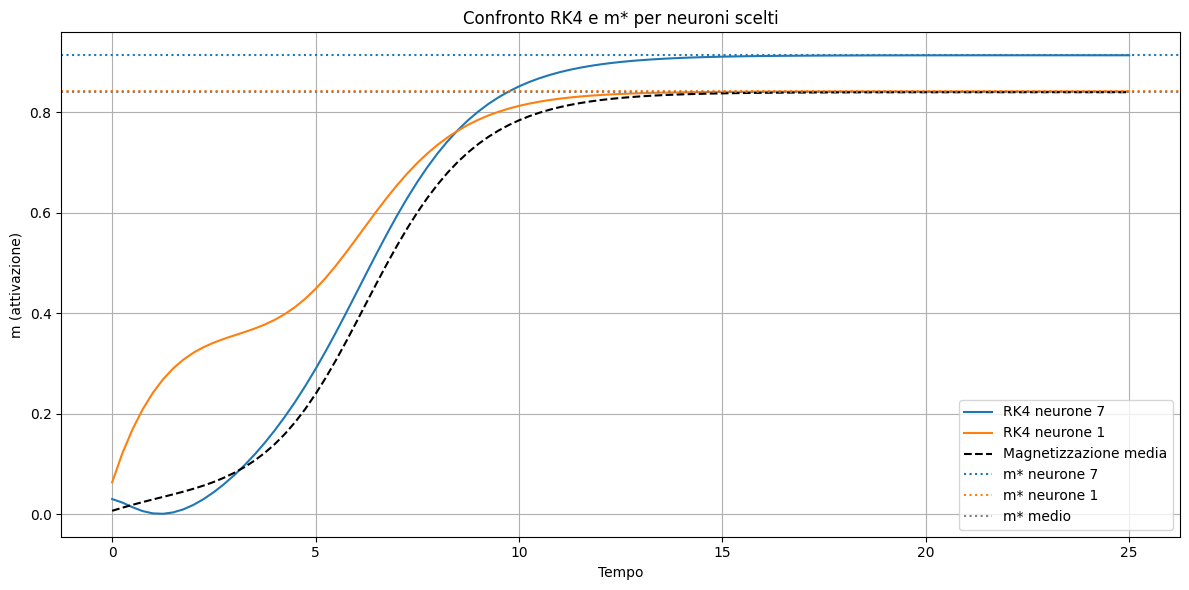

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Jacobiana grezza (non usata direttamente ma definita)
def J(m, W, b):
    diag = 1 - np.tanh(W @ m + b)**2
    return -np.eye(len(m)) + np.diag(diag) @ W

# Risoluzione sistema lineare con metodo Orthomin
def orthomin(A, b, tol=1e-8, max_iter=100):
    n = len(b)
    x = np.zeros(n)
    r = b - A @ x
    k = 0

    while np.linalg.norm(r) > tol and k < max_iter:
        Ar = A @ r
        alpha = np.dot(r, Ar) / np.dot(Ar, Ar) #alfa ottimale Orthomin
        x = x + alpha * r
        r = r - alpha * Ar #aggirno residuo
        k += 1

    return x

# Metodo di Newton con controllo norma E e errore relativo
def newton_method(F, J_func, m0, W, b, tol=1e-8, max_iter=100):
    m = m0.copy()
    i = 0
    f_val = F(m, W, b)
    norm_f = np.linalg.norm(f_val)

    while norm_f > tol and i < max_iter: #test
        diag = 1 - np.tanh(W @ m + b)**2
        E = diag[:, None] * W
        norm_E = np.linalg.norm(E, 2)

        if norm_E >= 1:
            epsilon = 1 / norm_E #determino epsilon
            E *= epsilon
            J = -np.eye(len(m)) + E #definisco J perturbata

            print(f"Iter {i}: ||E|| = {norm_E:.3f} ≥ 1 → uso epsilon = {epsilon:.3f}")

            # Calcolo errore relativo stimato
            J_norm = np.linalg.norm(J, 2)
            J_inv_norm = np.linalg.norm(np.linalg.inv(J), 2)
            cond_J = J_norm * J_inv_norm
            err_rel = cond_J * ((1 - epsilon) * norm_E / J_norm)
            print(f"→ Errore relativo stimato ≈ {err_rel:.3e} (cond = {cond_J:.2f})")
        else:
            print(f"Iter {i}: ||E|| = {norm_E:.3f} → OK")
            J = -np.eye(len(m)) + E

        #Risolvo il sitema
        delta = orthomin(J, f_val)
        #aggiorno m
        m = m - delta

        f_val = F(m, W, b) #aggiorno il valore di f
        norm_f = np.linalg.norm(f_val)
        norm_delta = np.linalg.norm(delta)

        print(f"→ ||f(m)|| = {norm_f:.3e}, ||delta|| = {norm_delta:.3e}")
        i += 1

    if norm_f < tol:
        print(f"Convergenza raggiunta in {i} iterazioni.")
    else:
        print("Newton non ha convergito")

    return m

# Esegui Newton (definisci F, m0, W, b prima di questa riga)
m_star = newton_method(F, J, m0, W, b)

# Calcolo della magnetizzazione (definisci 'traj' e 'time' prima)
magnetization = np.mean(traj, axis=1)

# Plot RK4 e m*
plt.figure(figsize=(12, 6))
plt.plot(time, traj[:, i], label=f"RK4 neurone {i}", color='tab:blue')
plt.plot(time, traj[:, j], label=f"RK4 neurone {j}", color='tab:orange')
plt.plot(time, magnetization, label="Magnetizzazione media", color='black', linestyle='--')
plt.axhline(m_star[i], color='tab:blue', linestyle=':', label=f"m* neurone {i}")
plt.axhline(m_star[j], color='tab:orange', linestyle=':', label=f"m* neurone {j}")
plt.axhline(np.mean(m_star), color='gray', linestyle=':', label="m* medio")
plt.title("Confronto RK4 e m* per neuroni scelti")
plt.xlabel("Tempo")
plt.ylabel("m (attivazione)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Convergenza del metodo Orthomin nel nostro problema

Il metodo **Orthomin** viene utilizzato per risolvere sistemi lineari iterativamente anche quando la matrice non è simmetrica o definita positiva.  
Nel nostro caso, applicandolo al sistema $J(m)\delta = f(m)$, ad ogni iterazione viene scelta una direzione in cui aggiornare $\delta^k$ in modo che il nuovo residuo $r^{k+1}$ sia **ortogonale a $J(m) r^k$**, garantendo che la sua **norma sia la minima possibile lungo quella direzione**.

---

Nel nostro contesto, il metodo **Orthomin** viene utilizzato per risolvere il sistema lineare:

$$
J(m)\delta = f(m), \quad \text{con} \quad J(m) = -I + D(m)W.
$$

Alla $k$-esima iterazione, il residuo viene aggiornato come:

$$
r^{k+1} = r^k - \alpha_k J(m) r^k, \quad \text{con} \quad \alpha_k = \frac{\langle r^k, J(m) r^k \rangle}{\|J(m) r^k\|^2}.
$$


Partiamo dall'espressione:

$$
\|r^{k+1}\|^2 = \langle r^{k+1}, r^{k+1} \rangle.
$$

Sostituendo la formula di aggiornamento:

$$
\begin{aligned}
\|r^{k+1}\|^2 &= \langle r^k - \alpha_k J(m) r^k,\; r^k - \alpha_k J(m) r^k \rangle \\
&= \langle r^k, r^k \rangle - 2\alpha_k \langle r^k, J(m) r^k \rangle + \alpha_k^2 \langle J(m) r^k,\; J(m) r^k \rangle \\
&= \|r^k\|^2 - 2\alpha_k \langle r^k, J(m) r^k \rangle + \alpha_k^2 \|J(m) r^k\|^2
\end{aligned}
$$

Ora sostituiamo $\alpha_k$:

$$
\begin{aligned}
\|r^{k+1}\|^2 &= \|r^k\|^2
- 2 \cdot \frac{\langle r^k, J(m) r^k \rangle}{\|J(m) r^k\|^2} \cdot \langle r^k, J(m) r^k \rangle
+ \left( \frac{\langle r^k, J(m) r^k \rangle}{\|J(m) r^k\|^2} \right)^2 \cdot \|J(m) r^k\|^2 \\
&= \|r^k\|^2 - \frac{2 \langle r^k, J(m) r^k \rangle^2}{\|J(m) r^k\|^2} + \frac{\langle r^k, J(m) r^k \rangle^2}{\|J(m) r^k\|^2} \\
&= \|r^k\|^2 - \frac{\langle r^k, J(m) r^k \rangle^2}{\|J(m) r^k\|^2}
\end{aligned}
$$


Osserviamo che:

- il termine sottratto è sempre **maggiore o uguale di zero**:

  $$
  \frac{\langle r^k, J(m) r^k \rangle^2}{\|J(m) r^k\|^2} \geq 0,
  $$

- quindi:

  $$
  \|r^{k+1}\| \leq \|r^k\|
  $$

- e si ha **stretta disuguaglianza** (cioè $\|r^{k+1}\| < \|r^k\|$) se e solo se:

  $$
  \langle r^k, J(m) r^k \rangle \neq 0.
  $$


Nel nostro algoritmo, questo è **garantito** perché:

- se $\|D(m)W\| \leq 1$, allora $J(m) = -I + D(m)W$ ha autovalori con parte reale negativa;
- se $\|D(m)W\| > 1$, usiamo una **versione scalata** $\tilde{J}(m) = -I + \varepsilon D(m)W$ con $\varepsilon = 1 / \|D(m)W\|$ per garantire che:

  $$
  0 \notin \text{spec}\big({J}(m)),
  $$

e quindi $\langle r^k, \tilde{J}(m) r^k \rangle \neq 0$.

Quindi **Orthomin converge** nel nostro metodo.


### Metodo di Newton con Jacobiana perturbata
Nelle iterazioni in cui invece di risolvere un sistema del tipo:

$$
J(m)\delta = -f(m)
$$

ne risolviamo un altro della forma:

$$
\tilde{J}(m)\tilde{\delta} = -f(m), \quad \text{con } \tilde{J}(m) = -I + \varepsilon D(m)W,
$$

siamo interessati a stimare la differenza tra la soluzione esatta del sistema e quella del sistema perturbato.

Poiché $ J(m) = -I + D(m)W $, la differenza tra le due Jacobiane è:

$$
\tilde{J}(m) - J(m) = (\varepsilon - 1) D(m)W
\quad \Rightarrow \quad
\|\tilde{J}(m) - J(m)\| = |1 - \varepsilon| \cdot \|D(m)W\|
$$

Ora, possiamo applicare un classico **teorema di perturbazione dei sistemi lineari**.

Partiamo dalle due equazioni:

- Sistema esatto: $ J \delta = b $
- Sistema perturbato: $ \tilde{J} \tilde{\delta} = b $

Sottraiamo membro a membro:

$$
\tilde{J} \tilde{\delta} - J \delta = 0
$$

Aggiungiamo e togliamo $ \tilde{J} \delta $:

$$
\tilde{J} \tilde{\delta} - \tilde{J} \delta + \tilde{J} \delta - J \delta
= \tilde{J}(\tilde{\delta} - \delta) + (\tilde{J} - J)\delta = 0
$$

quindi:

$$
\tilde{J}(\tilde{\delta} - \delta) = (J - \tilde{J}) \delta = -E \delta
$$

Poichè $ \tilde{J} $ è invertibile, moltiplichiamo entrambi i lati per $ \tilde{J}^{-1} $:

$$
\tilde{\delta} - \delta = -\tilde{J}^{-1} E \delta
$$

Prendendo la norma e applicando la disuguaglianza sub-multiplicativa:

$$
\|\tilde{\delta} - \delta\| \leq \|\tilde{J}^{-1}\| \cdot \|E\| \cdot \|\delta\|
$$

Dividendo per $ \|\delta\| $, otteniamo l’**errore relativo**:

$$
\frac{\|\tilde{\delta} - \delta\|}{\|\delta\|} \leq \|\tilde{J}^{-1}\| \cdot \|E\|
$$


Nel nostro caso specifico,

$$
\frac{\|\tilde{\delta} - \delta\|}{\|\delta\|} \leq K(J(m)) \cdot \frac{(1 - \varepsilon) \cdot \|D(m)W\|}{\|J(m)\|}
$$

dove \( K(J(m)) \) è il numero di condizionamento della Jacobiana originale.


### Osservazione:

Abbiamo usato il metodo di Newton, per le sue proprietà di convergenza infatti:

$$
e_k = m_k - m^* \quad \text{(errore al passo } k \text{)}
$$

Espandendo $f$ in serie di Taylor centrata in $m_k$:

$$
f(m^*) = f(m_k) + J(m_k)(m^* - m_k) + \frac{1}{2} H(\xi_k)[m^* - m_k]^2
$$

dove $H(\xi_k)$ è il tensore delle derivate seconde valutato in $\xi_k \in [m_k, m^*]$.

Poiché $f(m^*) = 0$, otteniamo:

$$
0 = f(m_k) - J(m_k)e_k + \frac{1}{2} H(\xi_k) e_k^2
$$

Sostituendo in Newton:

$$
e_{k+1} = m_{k+1} - m^* = m_k - J(m_k)^{-1}f(m_k) - m^*
$$

$$
= e_k - J(m_k)^{-1}f(m_k)
$$

Sostituendo l'espansione:

$$
e_{k+1} = e_k - J(m_k)^{-1}\left[ J(m_k)e_k - \frac{1}{2} H(\xi_k)e_k^2 \right]
$$

$$
= e_k - e_k + \frac{1}{2} J(m_k)^{-1} H(\xi_k) e_k^2
$$

$$
= \frac{1}{2} J(m_k)^{-1} H(\xi_k) e_k^2
$$

otteniamo quindi:

$$
\|e_{k+1}\| \leq C \|e_k\|^2 \quad \text{(con } C = \frac{1}{2} \|J(m_k)^{-1} H(\xi_k)\| \text{)}
$$

### Conclusione

La successione $\{m_k\}$ converge **quadraticamente** a $m^*$ se:

- $f$ è $\mathcal{C}^2$
- $J(m^*)$ è invertibile
- $m_0$ è sufficientemente vicino a $m^*$

Nel nostro caso:  
$f(m) = -m + \tanh(Wm + b)$ è $\mathcal{C}^\infty$ ⇒ ipotesi soddisfatte ⇒ convergenza quadratica garantita.



### Tornando alla regione di assolutà stabilità...

Per garantire che il metodo di Runge-Kutta 4 (RK4) sia **stabile** per la dinamica:

$$
\frac{dm}{dt} = -m + \tanh(Wm + b),
$$

linearizziamo l’equazione attorno a un punto $m^*$, ottenendo:

$$
\frac{d}{dt} (\delta m) = J(m^*) \, \delta m, \quad \text{con} \quad J(m) = -I + D(m)W,
$$

dove $D(m) = \operatorname{diag}(1 - \tanh^2(Wm + b))$ rappresenta la derivata locale della funzione di attivazione.


Nel caso lineare:

$$
\frac{dy}{dt} = \lambda y,
$$

RK4 è stabile se:

$$
z = \lambda \, \Delta t \in \mathcal{A}, \quad \text{con } \mathcal{A} = \left\{ z \in \mathbb{C} : |R(z)| < 1 \right\},
$$

dove la funzione di stabilità del metodo RK4 è:

$$
R(z) = 1 + z + \frac{z^2}{2} + \frac{z^3}{6} + \frac{z^4}{24}.
$$

La **regione reale di stabilità** è approssimativamente contenuta in $(-2.785, 0)$. Tuttavia, nel piano complesso la regione si restringe e curva, rendendo più restrittiva la stabilità in presenza di parti immaginarie.

Una condizione sufficiente conservativa è:

$$
\lambda_i \cdot \Delta t \in (-2, 0) \quad \Rightarrow \quad \Delta t < \frac{2}{|\lambda_{\min}|},
$$

dove $\lambda_{\min}$ è il più negativo (in valore assoluto) tra gli autovalori della Jacobiana per ogni soluzione $m$ di RK-4.

Cosa accade se $\lambda_i \cdot \Delta t \notin \mathcal{A}$?

Se anche **uno solo** degli autovalori moltiplicato per $\Delta t$ esce dalla regione $\mathcal{A}$, la traiettoria numerica ottenuta con RK4 può:

- Divergere (instabilità numerica),
- Oscillare senza convergere,
- Non approssimare più la soluzione reale.

Questo accade perché la funzione di amplificazione $R(z)$ supera 1 in modulo, amplificando gli errori a ogni passo.

---

### Possibile strategie

Se il sistema è **caotico** (ad esempio una matrice $W$ densa, o autovalori fuori scala), allora:

1. **Ridurre** il passo $\Delta t$ per riportare tutti i $\lambda_i \cdot \Delta t$ nella regione stabile, ma può rivelarsi empiricamente complesso.
2. Modificare la dinamica con un termine di damping (stabilizzante),

$$
\frac{dm}{dt} = \varepsilon(-m + \tanh(Wm + b))
$$

In questo modo:

- la dinamica è **più lenta**, ma più **stabile**;
- la **Jacobiana diventa**:

$$
J_\varepsilon(m) = \varepsilon(-I + D(m)W)
$$

In questo modo la dinamica è numericamente stabile anche in presenza di **spettro disperso** o **matrici  W  più dense, associate a più connesisoni sinaptiche**.

Questo consente di **stabilizzare numericamente** anche simulazioni che, con il passo scelto, uscirebbero dalla regione di stabilità di RK4.



Nel grafico seguente mostriamo:

- La **regione di assoluta stabilità** di RK4 nel piano complesso,
- Gli autovalori $\lambda_i(t) \cdot \Delta t$ calcolati lungo la dinamica simulata con RK4,
- La loro distribuzione temporale.

Già in questo sistema non complesso, con poche interazioni, si osserva che **alcuni autovalori escono dalla regione stabile**. In sistemi più caotici, tale fenomeno sarebbe ancora più evidente. Qaanto spesso è quindi evidnete come per trattare un sistema in cui interagiscono molteplici componenti, trovare funzionali che vengno minimizzati dal sistema per comprenderne il comportamento collettivo e capire le configurazioni verso cui si stabilizzano le varie componenti (comportamento emergente), come è stato fatto nel nostro caso ossia trovando la configurazione che minimizza l'energia libera con il metodo di Newton.

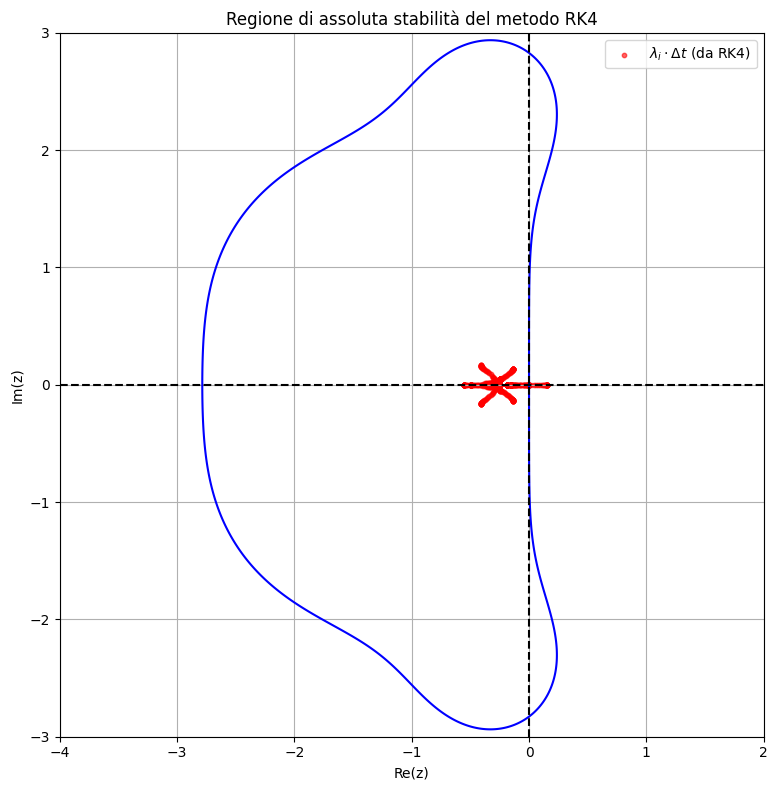

In [ ]:
def J(m, W, b):
    diag = 1 - np.tanh(W @ m + b)**2
    return -np.eye(len(m)) + np.diag(diag) @ W

# Calcolo autovalori di J(m) ad ogni passo del metodo RK-4
m = m0.copy()
eig_hist = [np.linalg.eigvals(J(m, W, b)) * dt]
for _ in range(N):
    m = rk4_step(F, m, W, b, dt) #calcolo la sol. a ogni istante temporale
    eig_hist.append(np.linalg.eigvals(J(m, W, b)) * dt) #trovo tutti gli autovalori all' i-esimo istante temporale con il metodo built-in di python
eig_hist = np.concatenate(eig_hist) #me li salvo

# Regione di stabilità RK4
def R(z):
    return 1 + z + z**2/2 + z**3/6 + z**4/24

#creo due griglie di valori per x e y
x = np.linspace(-4, 2, 800)
y = np.linspace(-3, 3, 800)
#crea una griglia nel piano
X, Y = np.meshgrid(x, y)
#combina le due griglie per formare un piano complesso
Z = X + 1j * Y
#per graficare la funzione modulo di R(z) nel piano complesso
mod_R = np.abs(R(Z))

# Plot
plt.figure(figsize=(8, 8))
plt.contour(X, Y, mod_R, levels=[1], colors='blue')
plt.scatter(eig_hist.real, eig_hist.imag, s=10, color='red', alpha=0.6, label=r"$\lambda_i \cdot \Delta t$ (da RK4)")
plt.axhline(0, color='black', linestyle='--')
plt.axvline(0, color='black', linestyle='--')
plt.title("Regione di assoluta stabilità del metodo RK4")
plt.xlabel("Re(z)")
plt.ylabel("Im(z)")
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()



## Conclusione
In questo progetto abbiamo modellato un sistema composto da molteplici componenti interagenti, rappresentandole come nodi di un grafo e descrivendo le loro relazioni tramite una funzione chiamata energia libera, che quantifica l'interazione globale del sistema.
Il principio guida è che il sistema tende spontaneamente a configurazioni che minimizzano questa energia, ovvero a stati di equilibrio collettivo.

Per esplorare come il sistema evolve verso questi stati, abbiamo simulato l’evoluzione temporale delle attivazioni di ogni componente utilizzando il metodo di Runge-Kutta 4, osservando come ciascun neurone tenda a stabilizzarsi nel tempo.
Abbiamo poi determinato direttamente i punti di equilibrio della dinamica tramite il metodo di Newton, trovando le configurazioni stabili del sistema che minimizzano proprio l'Energia libera.

Infine, confrontando la traiettoria simulata con le soluzioni stazionarie, abbiamo verificato che ogni componente tende nel tempo proprio a queste configurazioni di minimo, confermando la coerenza tra dinamica evolutiva e principio variazionale.

Questo approccio permette di analizzare e prevedere il comportamento di reti complesse in modo interpretabile e controllato.
È utile in ambiti critici come le neuroscienze, l’intelligenza artificiale, la finanza o la modellazione di sistemi dinamici complessi, dove comprendere  in quali stati si configurano le componenti del sistema è fondamentale per cogliere il comportamento emergente dell’intero insieme.
